# **Taller 06: Reducción de Dimensiones**
### Inteligencia Artificial ELP 8012 - Universidad del Norte - Profesor: Eduardo Zurek, PH.D. 
### **Grupo:** Natalia Carpintero, Paula Núñez e Isabella Arrieta.

Aplicar y comparar distintas técnicas de reducción de dimensiones (**PCA, MDS Clásico, MDS Métrico, MDS No-métrico y UMAP**) sobre datos de acelerómetro y giroscopio de teléfono y smartwatch, provenientes del **WISDM Smartphone and Smartwatch Activity and Biometrics Dataset**.

Para cada uno de los 4 casos (`phone-accel`, `phone-gyro`, `watch-accel`, `watch-gyro`):

1. Se seleccionan aleatoriamente **3 voluntarios** (de un total de 50, codificados de 1600 a 1650, sin el 1614).
2. Se construye, para cada voluntario, una matriz con las columnas `xyzbins` (`X0...X9`, `Y0...Y9`, `Z0...Z9`) y se define el *ground truth* con la columna `ACTIVITY`.
3. Se proyectan los datos a 2 dimensiones con cada técnica, coloreando por `ACTIVITY`.
4. Se repite el proceso uniendo las 3 muestras en una sola matriz por caso.


## 1. Descarga y ubicación del dataset

El dataset se descarga desde el repositorio UCI:

> https://archive.ics.uci.edu/dataset/507/wisdm+smartphone+and+smartwatch+activity+and+biometrics+dataset

Descomprima el archivo `wisdm-dataset.zip` en la misma carpeta de este notebook. La estructura esperada es:

```
wisdm-dataset/
└── arff_files/
    ├── phone/
    │   ├── accel/
    │   │   ├── data_1600_accel_phone.arff
    │   │   ├── data_1601_accel_phone.arff
    │   │   └── ...
    │   └── gyro/
    │       ├── data_1600_gyro_phone.arff
    │       └── ...
    └── watch/
        ├── accel/
        │   ├── data_1600_accel_watch.arff
        │   └── ...
        └── gyro/
            ├── data_1600_gyro_watch.arff
            └── ...
```

Cada archivo `.arff` contiene, entre otras columnas, las 30 columnas `xyzbins` (`X0..X9`, `Y0..Y9`, `Z0..Z9`) —histogramas de las lecturas del sensor— y la columna de clase con la actividad realizada (`ACTIVITY` o `class`, según la versión del dataset).

Ajuste la variable `DATA_DIR` en la siguiente celda según donde haya descomprimido el dataset.


In [ ]:
# Si hace falta, instale las dependencias (descomente en su entorno local)
%pip install -q pandas numpy scipy scikit-learn matplotlib seaborn umap-learn


In [1]:
import os
import re
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import arff as scipy_arff
from scipy.spatial.distance import pdist, squareform

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS

import umap

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42  # semilla para reproducibilidad de los algoritmos (no de la selección de voluntarios)
np.random.seed(RANDOM_STATE)


C:\Users\USUARIO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Ruta base donde se descomprimió el dataset.
# Se prueban las dos ubicaciones habituales según desde dónde se abrió el notebook.
DATA_DIR_CANDIDATES = [
    Path("./wisdm-dataset/arff_files"),
    Path("./Taller6-Reduccion-de-dimensiones/wisdm-dataset/arff_files"),
]
DATA_DIR = next((path for path in DATA_DIR_CANDIDATES if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "No se encontró 'wisdm-dataset/arff_files'. "
        "Ajuste DATA_DIR_CANDIDATES a la ubicación del dataset."
    )
print(f"Dataset encontrado en: {DATA_DIR.resolve()}")

DEVICES = ["phone", "watch"]
SENSORS = ["accel", "gyro"]
CASES = [(d, s) for d in DEVICES for s in SENSORS]  # phone-accel, phone-gyro, watch-accel, watch-gyro

def arff_path(subject_id, device, sensor):
    """Construye la ruta al archivo .arff de un voluntario/dispositivo/sensor."""
    fname = f"data_{subject_id}_{sensor}_{device}.arff"
    return DATA_DIR / device / sensor / fname

Dataset encontrado en: C:\Users\USUARIO\Downloads\Taller6-Reduccion-de-dimensiones\wisdm-dataset\arff_files


## 2. Selección aleatoria de 3 voluntarios

Los voluntarios están codificados de **1600 a 1650**, sin el **1614** (50 voluntarios en total). Seleccionamos 3 de ellos aleatoriamente.


In [3]:
ALL_SUBJECTS = [s for s in range(1600, 1651) if s != 1614]
assert len(ALL_SUBJECTS) == 50, "Se esperaban 50 voluntarios"

SELECTED_SUBJECTS = random.sample(ALL_SUBJECTS, 3)
print("Voluntarios seleccionados:", SELECTED_SUBJECTS)


Voluntarios seleccionados: [1644, 1641, 1628]


## 3. Carga de datos

Definimos una función que, dado un voluntario, dispositivo y sensor, carga el archivo `.arff` correspondiente y devuelve una matriz con las **30 columnas xyzbins** (`X0..X9`, `Y0..Y9`, `Z0..Z9`) junto con la columna `ACTIVITY` (ground truth).


In [4]:
# ==================== DEFINICIÓN DE load_case ====================

BIN_COL_PATTERN = re.compile(r"^[XYZ][0-9]$")

def load_case(subject_id, device, sensor):
    """Carga un archivo .arff y devuelve (X, y):
        X: DataFrame con las columnas xyzbins (X0..X9, Y0..Y9, Z0..Z9)
        y: Serie con la actividad (ground truth)"""
    path = arff_path(subject_id, device, sensor)
    data, meta = scipy_arff.loadarff(path)
    df = pd.DataFrame(data)
    # scipy.io.arff conserva las comillas del encabezado en los nombres.
    df.columns = [str(col).strip('"') for col in df.columns]

    # Decodificar columnas de tipo bytes (típico en ARFF con atributos nominales)
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].apply(lambda v: v.decode("utf-8") if isinstance(v, bytes) else v)

    # Identificar la columna de la clase (ACTIVITY / class)
    label_col = None
    for candidate in ["ACTIVITY", "class", "Class", "activity"]:
        if candidate in df.columns:
            label_col = candidate
            break
    if label_col is None:
        label_col = df.columns[-1]  # último recurso: última columna

    bin_cols = [c for c in df.columns if BIN_COL_PATTERN.match(c)]
    assert len(bin_cols) == 30, f"Se esperaban 30 columnas xyzbins, se encontraron {len(bin_cols)}: {bin_cols}"

    X = df[bin_cols].astype(float)
    y = df[label_col].astype(str)
    y.name = "ACTIVITY"
    
    return X, y


In [5]:
def load_case_safe(subject_id, device, sensor):
    """Igual que load_case, pero captura errores de archivo faltante/corrupto."""
    try:
        return load_case(subject_id, device, sensor)
    except FileNotFoundError:
        print(f"[Aviso] No se encontró el archivo para sujeto {subject_id}, {device}-{sensor}.")
        return None, None


## 4. Funciones de reducción de dimensiones

Implementamos las 5 técnicas solicitadas:

- **PCA**: `sklearn.decomposition.PCA`
- **MDS Clásico** (Torgerson, vía eigendescomposición de la matriz de distancias doblemente centrada) — implementado manualmente porque `scikit-learn` sólo ofrece la variante iterativa (SMACOF).
- **MDS Métrico** (SMACOF, `metric=True`)
- **MDS No-métrico** (SMACOF, `metric=False`)
- **UMAP**: `umap.UMAP`

Antes de reducir, estandarizamos las variables (media 0, varianza 1) para que ningún bin domine por escala.


In [6]:
def classical_mds(X, n_components=2):
    """MDS clásico (Torgerson) vía eigendescomposición de la matriz de
    distancias euclidianas doblemente centrada (equivalente a PCoA)."""
    D = squareform(pdist(X, metric="euclidean"))
    n = D.shape[0]
    D2 = D ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J

    eigvals, eigvecs = np.linalg.eigh(B)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    pos_idx = eigvals > 0
    L = np.diag(np.sqrt(eigvals[pos_idx][:n_components]))
    V = eigvecs[:, pos_idx][:, :n_components]
    return V @ L


def reduce_dimensions(X, random_state=RANDOM_STATE, verbose=True):
    """Aplica las 5 técnicas de reducción de dimensiones y devuelve un
    diccionario {nombre_tecnica: embedding_2D}.

    Se usan los hiperparámetros por defecto de scikit-learn / umap-learn
    (sin ajustes para acelerar el cómputo), por lo que el tiempo total de
    ejecución del notebook es mayor, especialmente en los casos combinados
    (hasta ~1500 muestras)."""
    Xs = StandardScaler().fit_transform(X)
    embeddings = {}

    if verbose:
        print(f"Reduciendo {len(X)} muestras de {X.shape[1]} dimensiones...")

    # PCA
    if verbose: print("  • PCA...", end=" ", flush=True)
    embeddings["PCA"] = PCA(n_components=2, random_state=random_state).fit_transform(Xs)
    if verbose: print("✓")

    # MDS Clásico
    if verbose: print("  • MDS Clásico...", end=" ", flush=True)
    embeddings["MDS Clásico"] = classical_mds(Xs, n_components=2)
    if verbose: print("✓")

    # MDS Métrico (hiperparámetros por defecto: n_init=4, max_iter=300)
    if verbose: print("  • MDS Métrico...", end=" ", flush=True)
    embeddings["MDS Métrico"] = MDS(
        n_components=2, metric=True, dissimilarity="euclidean",
        random_state=random_state, normalized_stress="auto"
    ).fit_transform(Xs)
    if verbose: print("✓")

    # MDS No-métrico (hiperparámetros por defecto: n_init=4, max_iter=300)
    if verbose: print("  • MDS No-métrico...", end=" ", flush=True)
    embeddings["MDS No-métrico"] = MDS(
        n_components=2, metric=False, dissimilarity="euclidean",
        random_state=random_state, normalized_stress="auto"
    ).fit_transform(Xs)
    if verbose: print("✓")

    # UMAP (hiperparámetros por defecto: n_neighbors=15, n_epochs=None -> automático)
    if verbose: print("  • UMAP...", end=" ", flush=True)
    embeddings["UMAP"] = umap.UMAP(
        n_components=2, random_state=random_state, verbose=False
    ).fit_transform(Xs)
    if verbose: print("✓")

    if verbose: print("Listo!\n")
    return embeddings


### Nota metodológica: hiperparámetros por defecto

Esta versión del notebook usa los **hiperparámetros por defecto** de `scikit-learn` y `umap-learn`, sin ajustes para acelerar el cómputo:

- **MDS Métrico y No-métrico:** `n_init=4` (4 inicializaciones aleatorias, se conserva la de menor *stress*) y `max_iter=300`, los valores por defecto de `sklearn.manifold.MDS`. Esto hace que el resultado sea más robusto frente a óptimos locales que con una sola inicialización, pero el tiempo de cómputo es notablemente mayor (cada caso combinado —hasta ~1500 muestras— puede tardar varios minutos).
- **UMAP:** `n_neighbors=15` y número de épocas automático (`n_epochs=None`), según el tamaño de cada muestra.

Como referencia, con 3 voluntarios y 4 casos (12 análisis individuales + 4 combinados = 16 reducciones completas), la ejecución total puede tomar bastante más tiempo que con parámetros reducidos. Si el entorno es limitado (por ejemplo, sin GPU o con pocos núcleos), puede tardar entre 20 y 60 minutos dependiendo del hardware.


In [7]:
def plot_embeddings(embeddings, y, title, figsize=(24, 4.5)):
    """Grafica en una fila los 5 embeddings 2D, coloreados por ACTIVITY."""
    techniques = list(embeddings.keys())
    fig, axes = plt.subplots(1, len(techniques), figsize=figsize)
    fig.suptitle(title, fontsize=14, y=1.05)

    activities = sorted(y.unique())
    palette = sns.color_palette("tab20", n_colors=len(activities))
    color_map = dict(zip(activities, palette))

    for ax, tech in zip(axes, techniques):
        emb = embeddings[tech]
        for act in activities:
            mask = (y == act).values
            ax.scatter(emb[mask, 0], emb[mask, 1], s=12, color=color_map[act], label=act, alpha=0.8)
        ax.set_title(tech, fontsize=11)
        ax.set_xlabel("Dim 1")
        ax.set_ylabel("Dim 2")

    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5),
               fontsize=8, title="ACTIVITY", ncol=1)
    plt.tight_layout()
    plt.show()


## 5. Análisis individual por muestra

Para cada uno de los 3 voluntarios seleccionados y cada uno de los 4 casos (`phone-accel`, `phone-gyro`, `watch-accel`, `watch-gyro`), cargamos la matriz `xyzbins`.

Los datos crudos (`X`, `y`) de cada muestra se guardan para poder combinarlos en la siguiente fase.

**Ejecución:** Ejecuta esta celda para cargar todos los datos.



In [8]:
# FASE 1: Cargar datos individuales por voluntario (SIN GRÁFICAS)
print("=" * 70)
print("FASE 1: Cargando datos individuales por voluntario")
print("=" * 70)

raw_data = {}  # Diccionario para almacenar datos crudos

for i, subject_id in enumerate(SELECTED_SUBJECTS):
    print(f"\nVoluntario {i+1}/3: {subject_id}")
    for device, sensor in CASES:
        case_name = f"{device}-{sensor}"
        print(f"  • Cargando {case_name}...", end=" ", flush=True)
        X, y = load_case_safe(subject_id, device, sensor)
        if X is None:
            print("❌")
            continue
        raw_data[(subject_id, case_name)] = (X, y)
        print(f"✓ ({len(y)} muestras)")

print("\n" + "=" * 70)
print("✓ Fase 1 completada")
print("=" * 70)


FASE 1: Cargando datos individuales por voluntario

Voluntario 1/3: 1644
  • Cargando phone-accel... ✓ (803 muestras)
  • Cargando phone-gyro... ✓ (379 muestras)
  • Cargando watch-accel... ✓ (351 muestras)
  • Cargando watch-gyro... ✓ (351 muestras)

Voluntario 2/3: 1641
  • Cargando phone-accel... ✓ (803 muestras)
  • Cargando phone-gyro... ✓ (379 muestras)
  • Cargando watch-accel... ✓ (324 muestras)
  • Cargando watch-gyro... ✓ (323 muestras)

Voluntario 3/3: 1628
  • Cargando phone-accel... ✓ (541 muestras)
  • Cargando phone-gyro... ✓ (321 muestras)
  • Cargando watch-accel... ✓ (351 muestras)
  • Cargando watch-gyro... ✓ (351 muestras)

✓ Fase 1 completada


## 6. Reducción de dimensiones individual

Aplicamos PCA, MDS Clásico, MDS Métrico, MDS No-métrico y UMAP a cada matriz individual guardada en la fase anterior. Las gráficas se mostrarán después de terminar también el procesamiento combinado.



In [9]:
print("\n" + "=" * 70)
print("FASE 2: Aplicando técnicas a cada muestra individual")
print("=" * 70 + "\n")

individual_results = {}

for (subject_id, case_name), (X, y) in raw_data.items():
    print(f"Procesando voluntario {subject_id}, {case_name}...", flush=True)
    individual_results[(subject_id, case_name)] = (
        reduce_dimensions(X, verbose=True),
        y
    )

print("=" * 70)
print("✓ Fase 2 completada")
print("=" * 70)



FASE 2: Aplicando técnicas a cada muestra individual

Procesando voluntario 1644, phone-accel...
Reduciendo 803 muestras de 30 dimensiones...
  • PCA... ✓
  • MDS Clásico... ✓
  • MDS Métrico... ✓
  • MDS No-métrico... ✓
  • UMAP... ✓
Listo!

Procesando voluntario 1644, phone-gyro...
Reduciendo 379 muestras de 30 dimensiones...
  • PCA... ✓
  • MDS Clásico... ✓
  • MDS Métrico... ✓
  • MDS No-métrico... ✓
  • UMAP... ✓
Listo!

Procesando voluntario 1644, watch-accel...
Reduciendo 351 muestras de 30 dimensiones...
  • PCA... ✓
  • MDS Clásico... ✓
  • MDS Métrico... ✓
  • MDS No-métrico... ✓
  • UMAP... ✓
Listo!

Procesando voluntario 1644, watch-gyro...
Reduciendo 351 muestras de 30 dimensiones...
  • PCA... ✓
  • MDS Clásico... ✓
  • MDS Métrico... ✓
  • MDS No-métrico... ✓
  • UMAP... ✓
Listo!

Procesando voluntario 1641, phone-accel...
Reduciendo 803 muestras de 30 dimensiones...
  • PCA... ✓
  • MDS Clásico... ✓
  • MDS Métrico... ✓
  • MDS No-métrico... ✓
  • UMAP... ✓
Listo!

Pr

## 7. Análisis combinado por caso

Para cada caso (`phone-accel`, `phone-gyro`, `watch-accel`, `watch-gyro`), unimos la información de los 3 voluntarios en una sola matriz y aplicamos las 5 técnicas de reducción de dimensiones.

**Nota:** Esta fase es la más costosa computacionalmente (20-30 minutos). Los indicadores de progreso mostrarán el avance de cada técnica.

**Ejecución:** Ejecuta esta celda después de la reducción individual.



In [10]:
print("\n" + "=" * 70)
print("FASE 3: Procesando análisis combinado por caso")
print("=" * 70 + "\n")

combined_results = {}

for device, sensor in CASES:
    case_name = f"{device}-{sensor}"
    print(f"Procesando {case_name}...", flush=True)

    Xs_list, ys_list = [], []
    for subject_id in SELECTED_SUBJECTS:
        if (subject_id, case_name) in raw_data:
            X_s, y_s = raw_data[(subject_id, case_name)]
            Xs_list.append(X_s)
            ys_list.append(y_s)

    if not Xs_list:
        print(f"  [Aviso] No hay datos disponibles\n")
        continue

    X_combined = pd.concat(Xs_list, axis=0, ignore_index=True)
    y_combined = pd.concat(ys_list, axis=0, ignore_index=True)

    embeddings = reduce_dimensions(X_combined, verbose=True)
    combined_results[case_name] = (embeddings, y_combined)

print("=" * 70)
print("✓ Fase 3 completada")
print("=" * 70)



FASE 3: Procesando análisis combinado por caso

Procesando phone-accel...
Reduciendo 2147 muestras de 30 dimensiones...
  • PCA... ✓
  • MDS Clásico... ✓
  • MDS Métrico... ✓
  • MDS No-métrico... ✓
  • UMAP... ✓
Listo!

Procesando phone-gyro...
Reduciendo 1079 muestras de 30 dimensiones...
  • PCA... ✓
  • MDS Clásico... ✓
  • MDS Métrico... ✓
  • MDS No-métrico... ✓
  • UMAP... ✓
Listo!

Procesando watch-accel...
Reduciendo 1026 muestras de 30 dimensiones...
  • PCA... ✓
  • MDS Clásico... ✓
  • MDS Métrico... ✓
  • MDS No-métrico... ✓
  • UMAP... ✓
Listo!

Procesando watch-gyro...
Reduciendo 1025 muestras de 30 dimensiones...
  • PCA... ✓
  • MDS Clásico... ✓
  • MDS Métrico... ✓
  • MDS No-métrico... ✓
  • UMAP... ✓
Listo!

✓ Fase 3 completada


## 8. Visualización de resultados individuales

Esta celda muestra las 12 figuras individuales: una por cada voluntario y caso. Cada figura contiene las cinco técnicas de reducción, coloreadas por `ACTIVITY`.



FASE 4: Visualizando resultados individuales



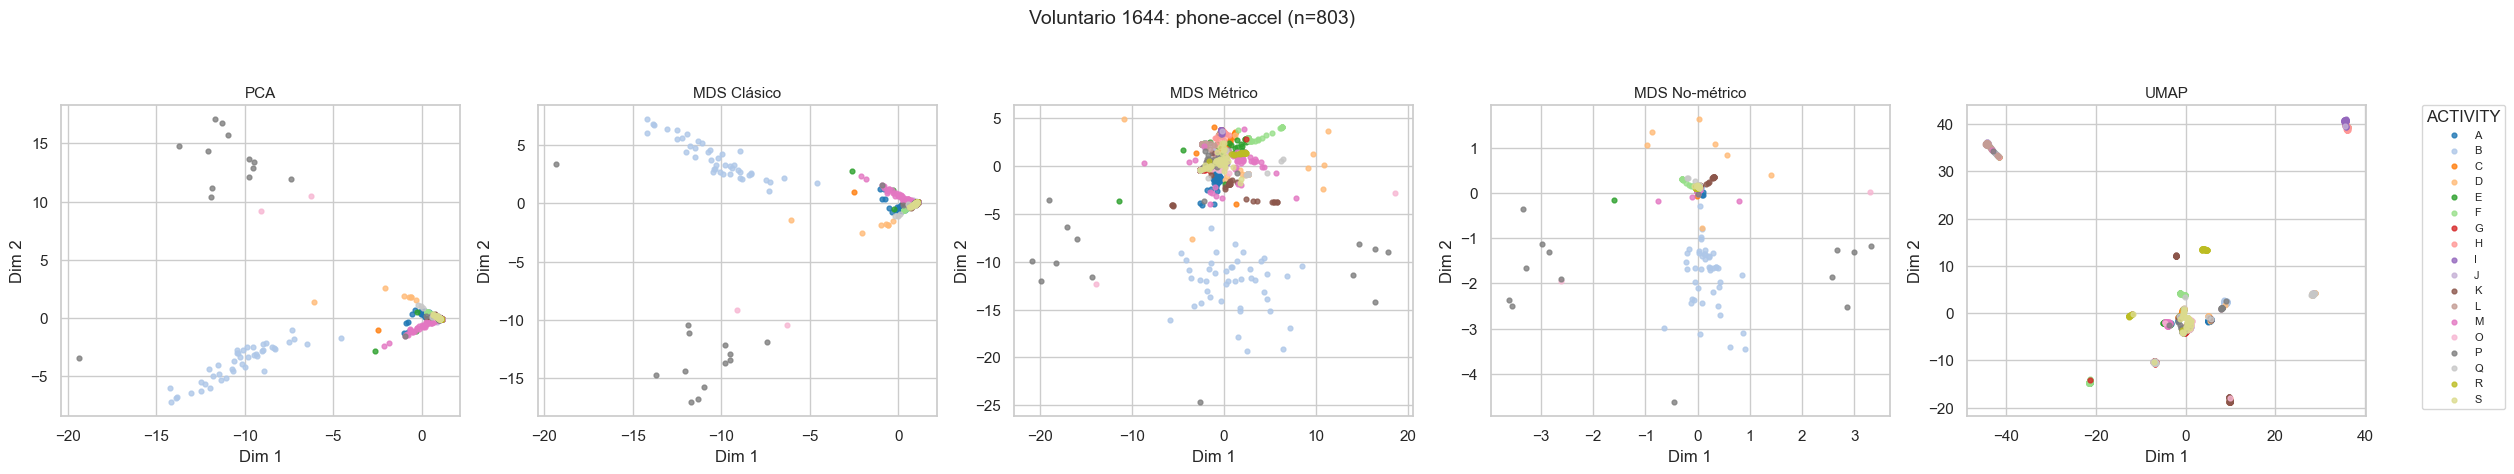

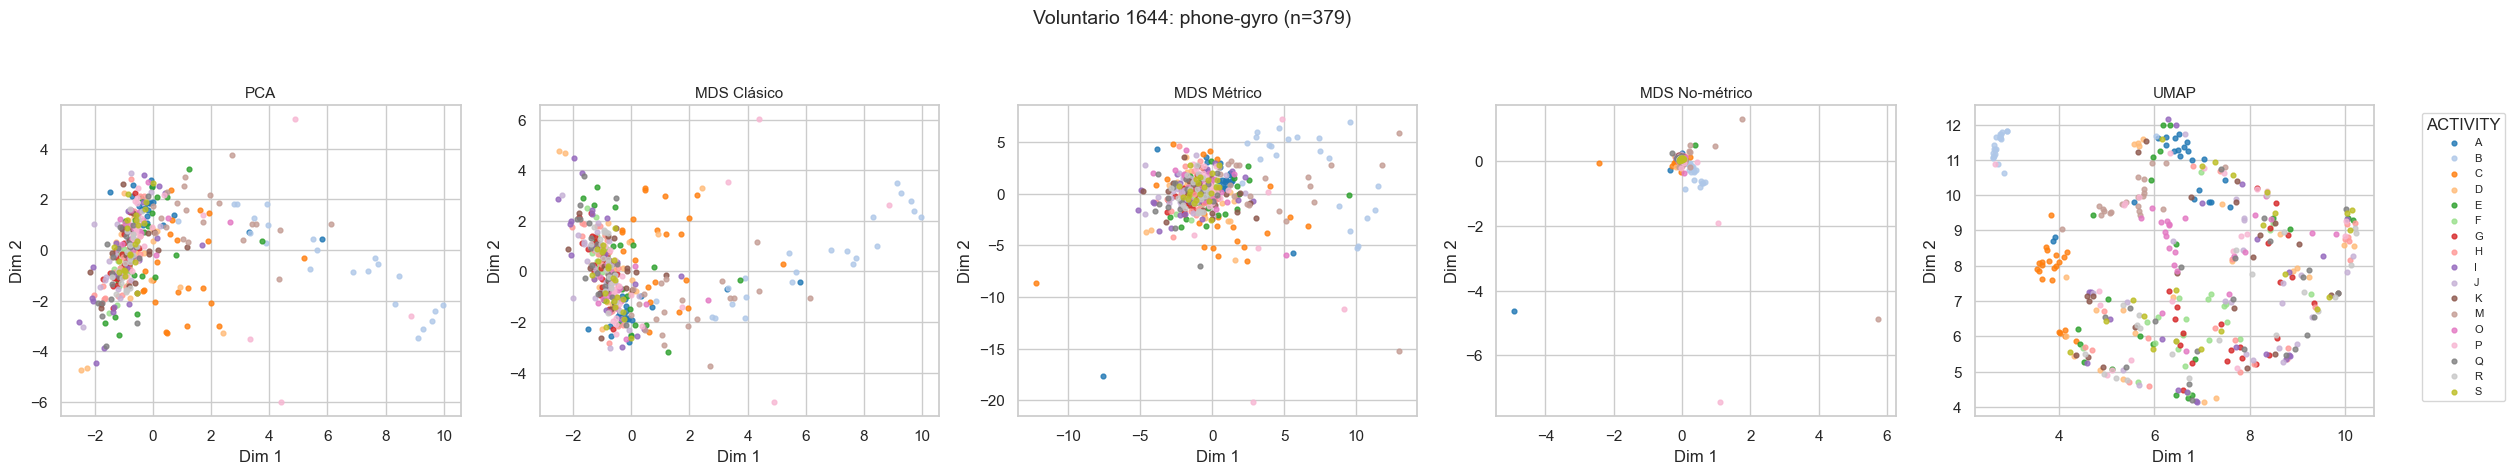

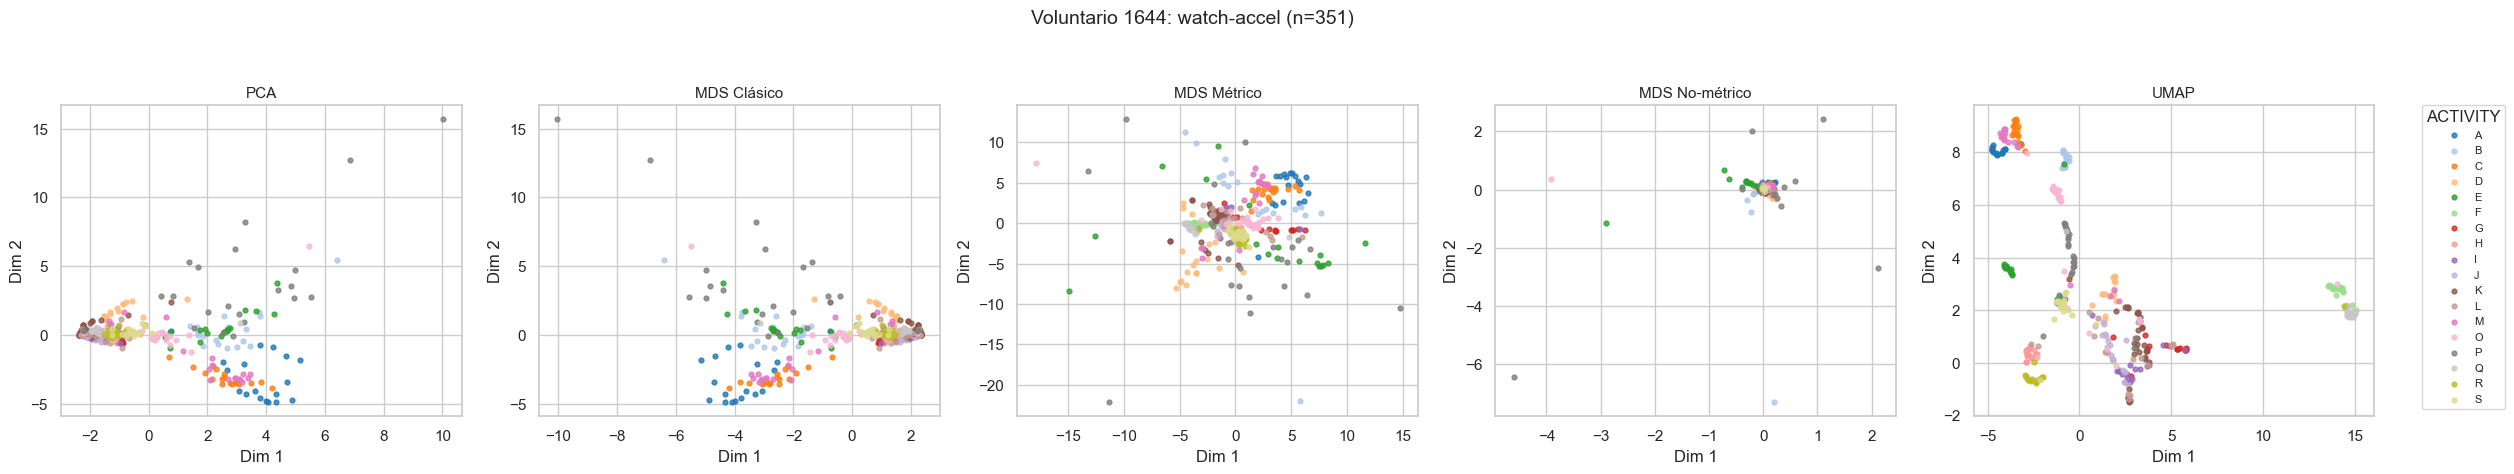

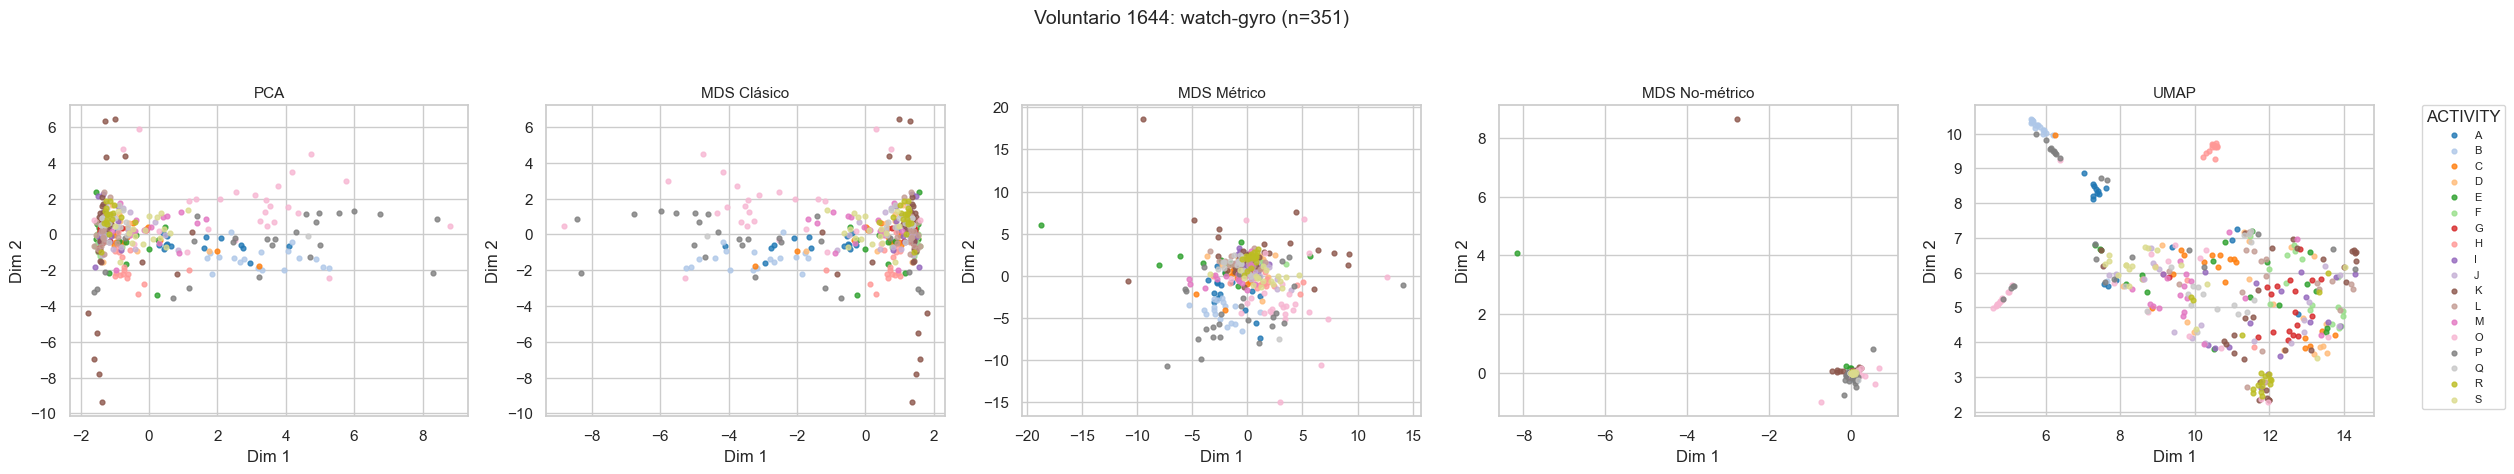

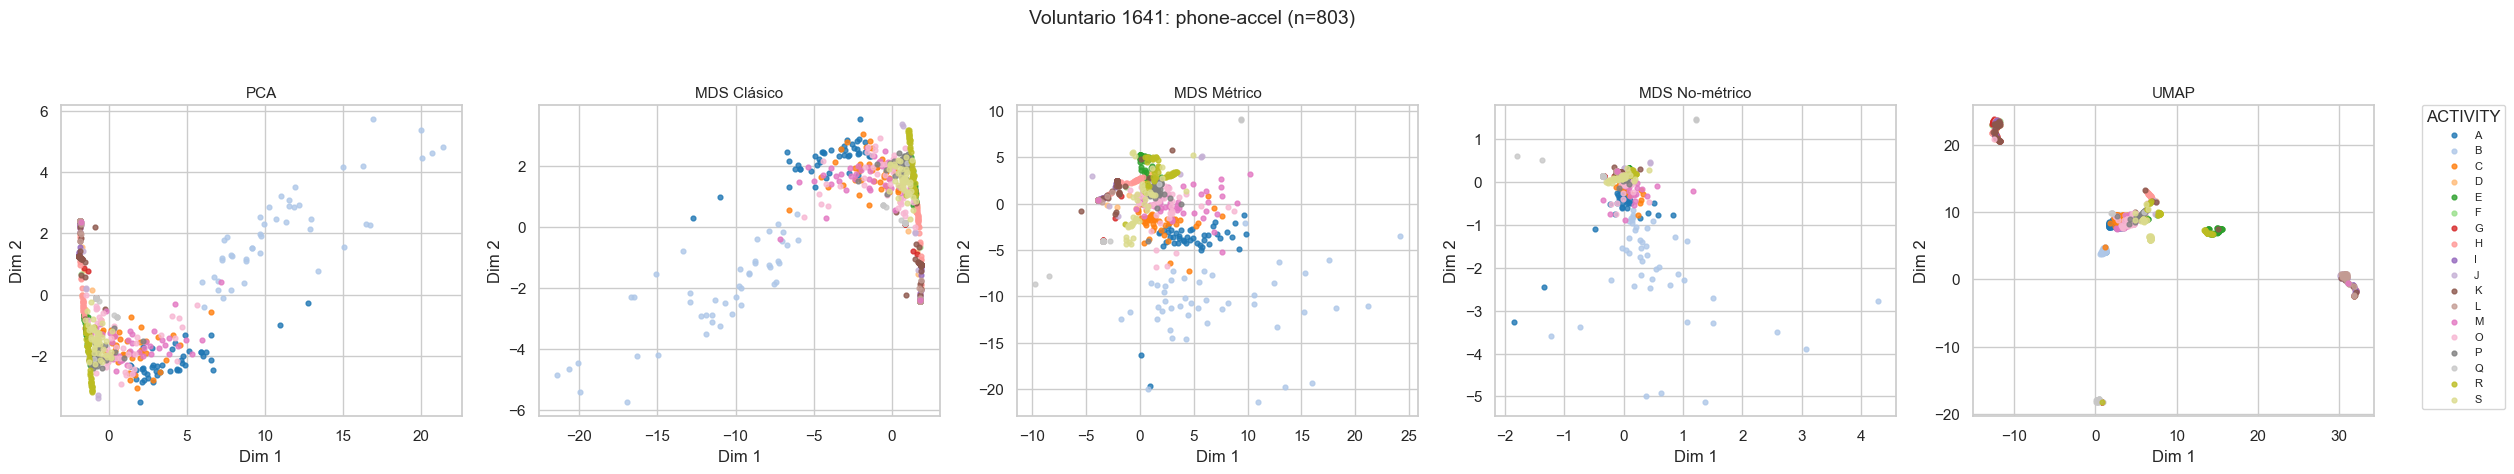

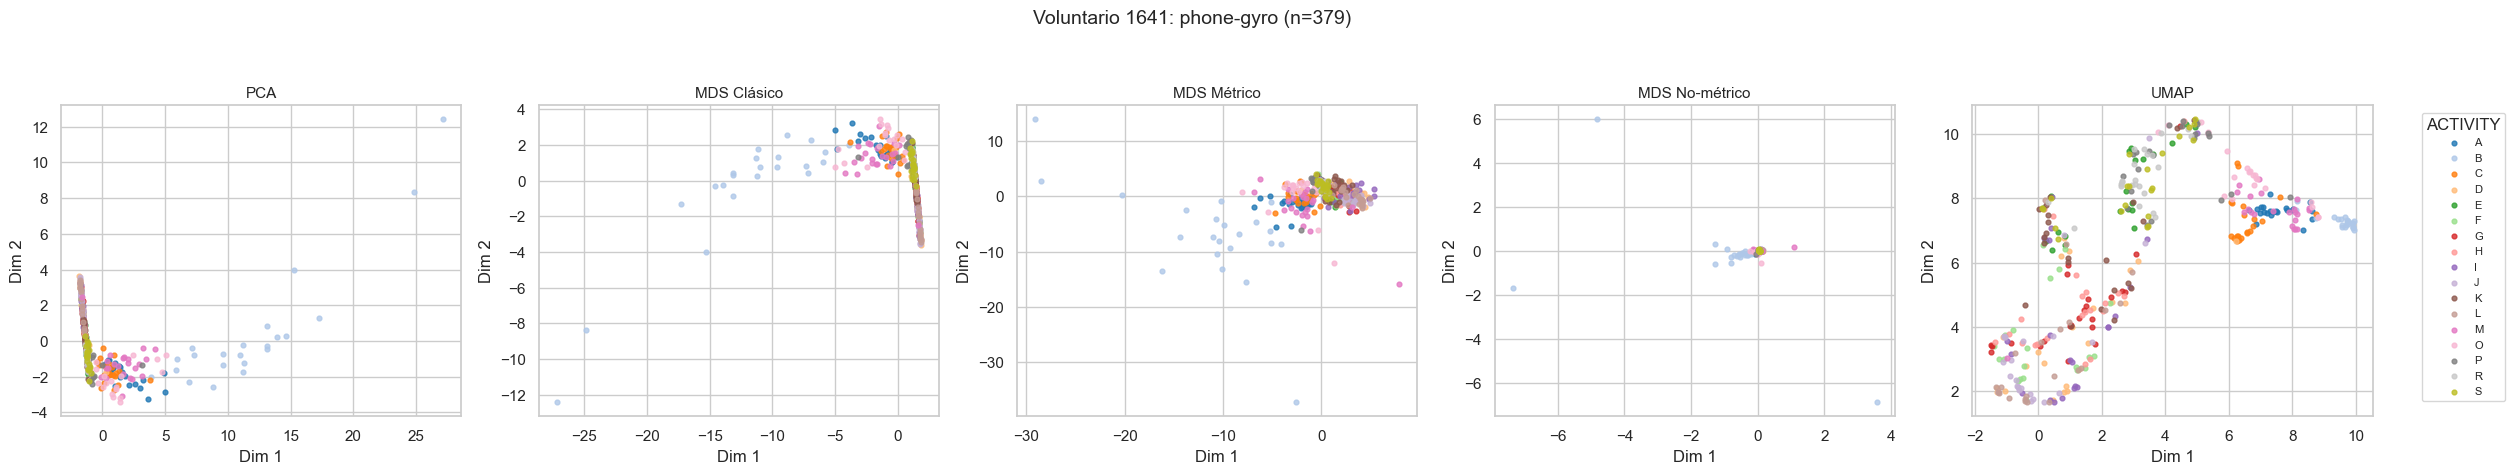

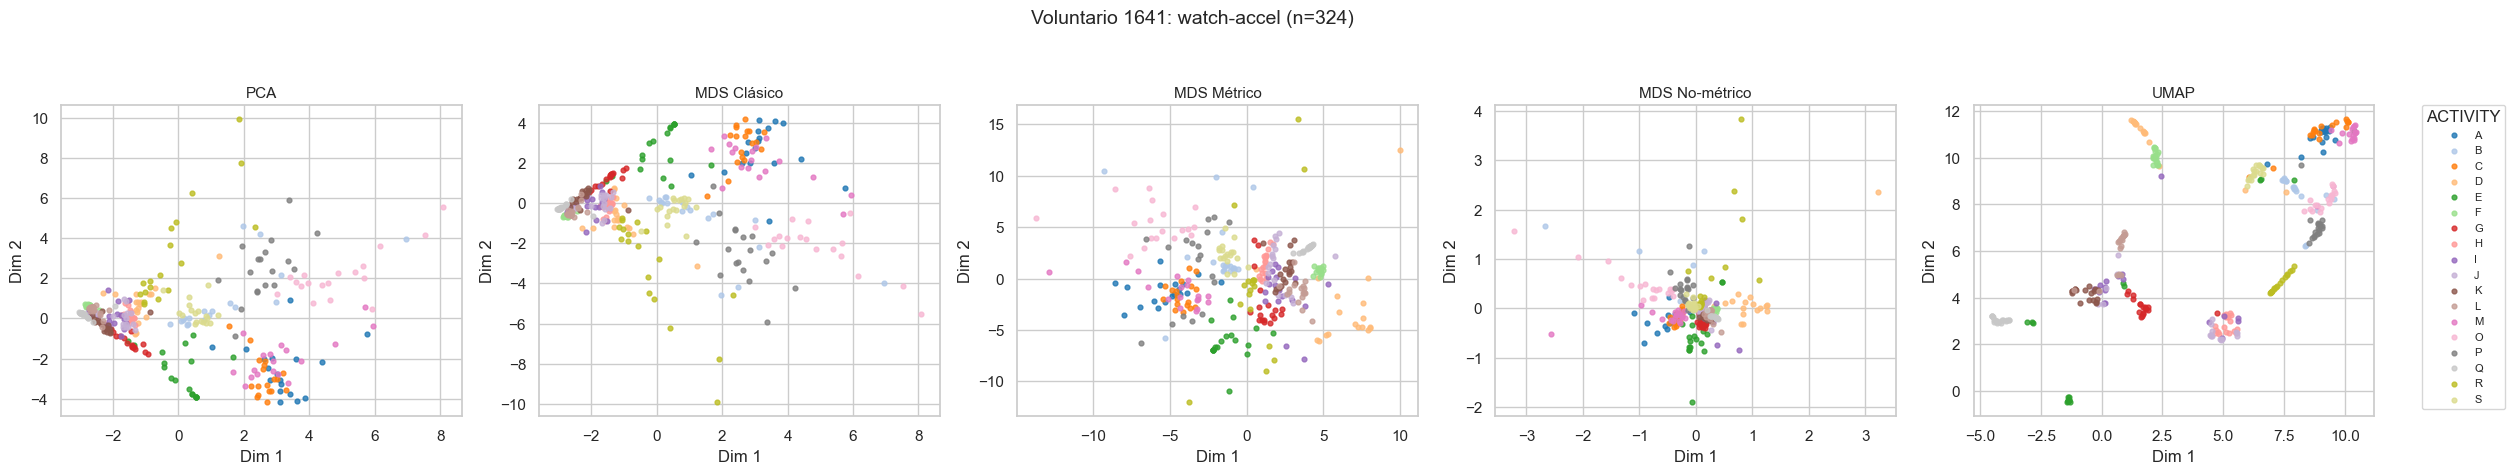

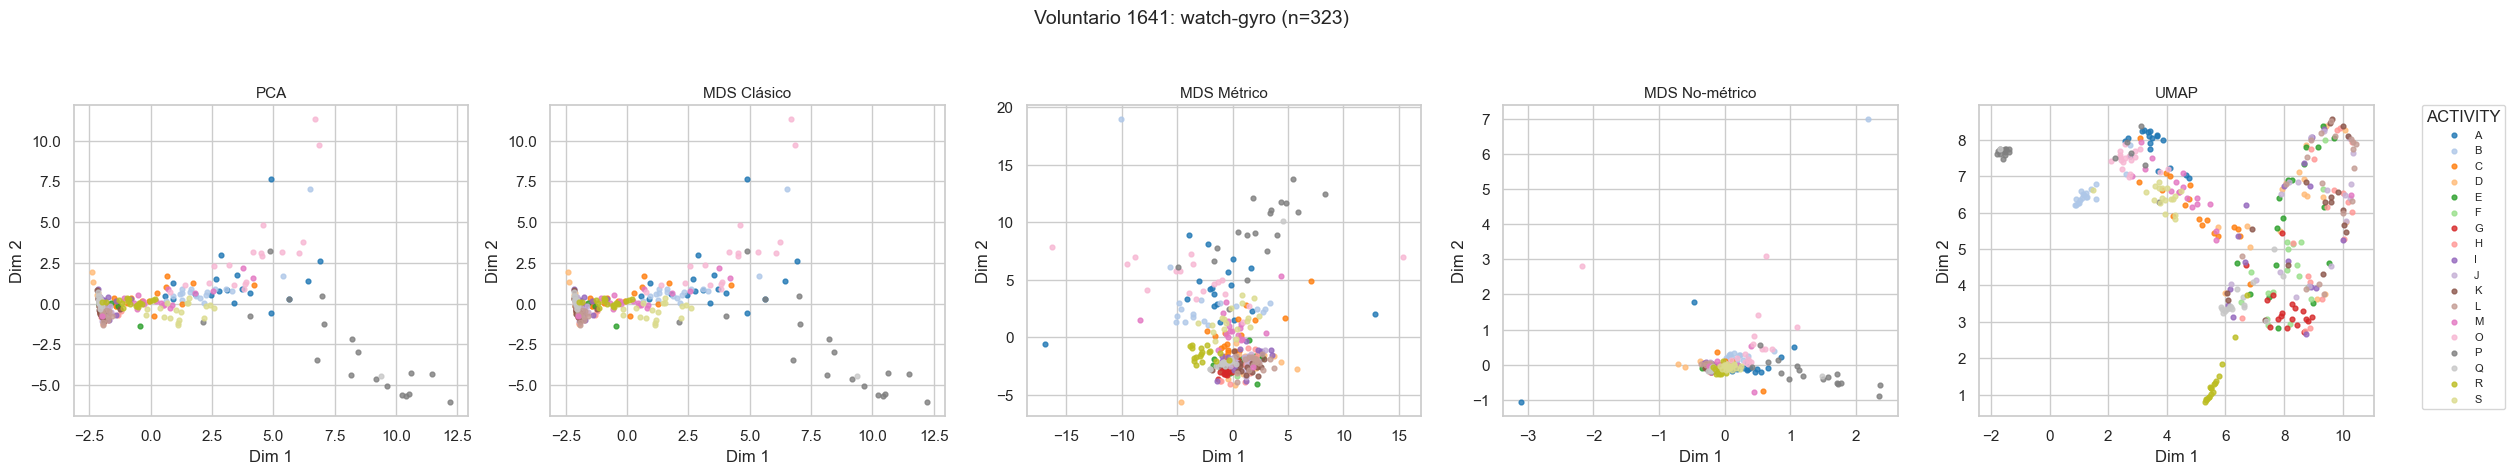

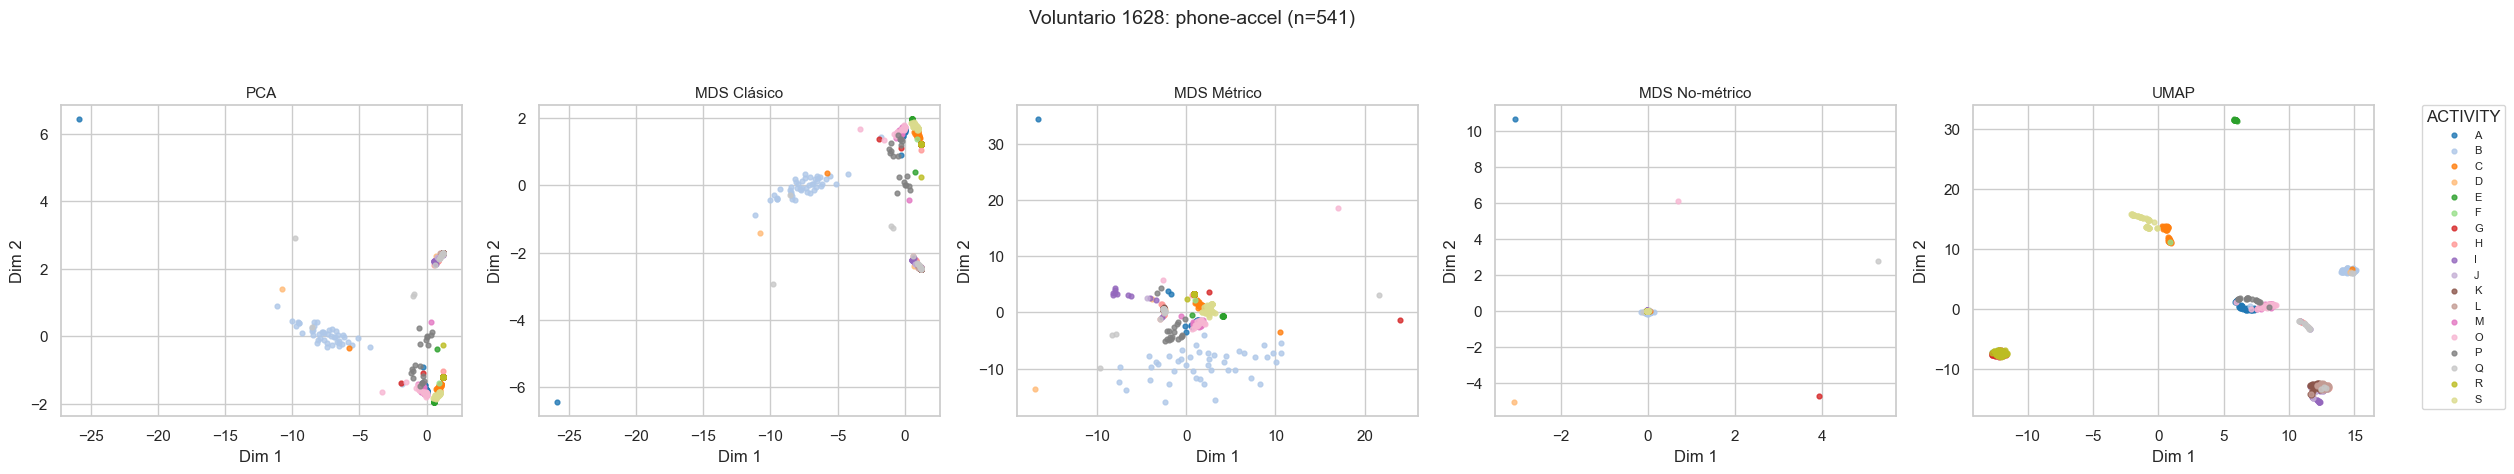

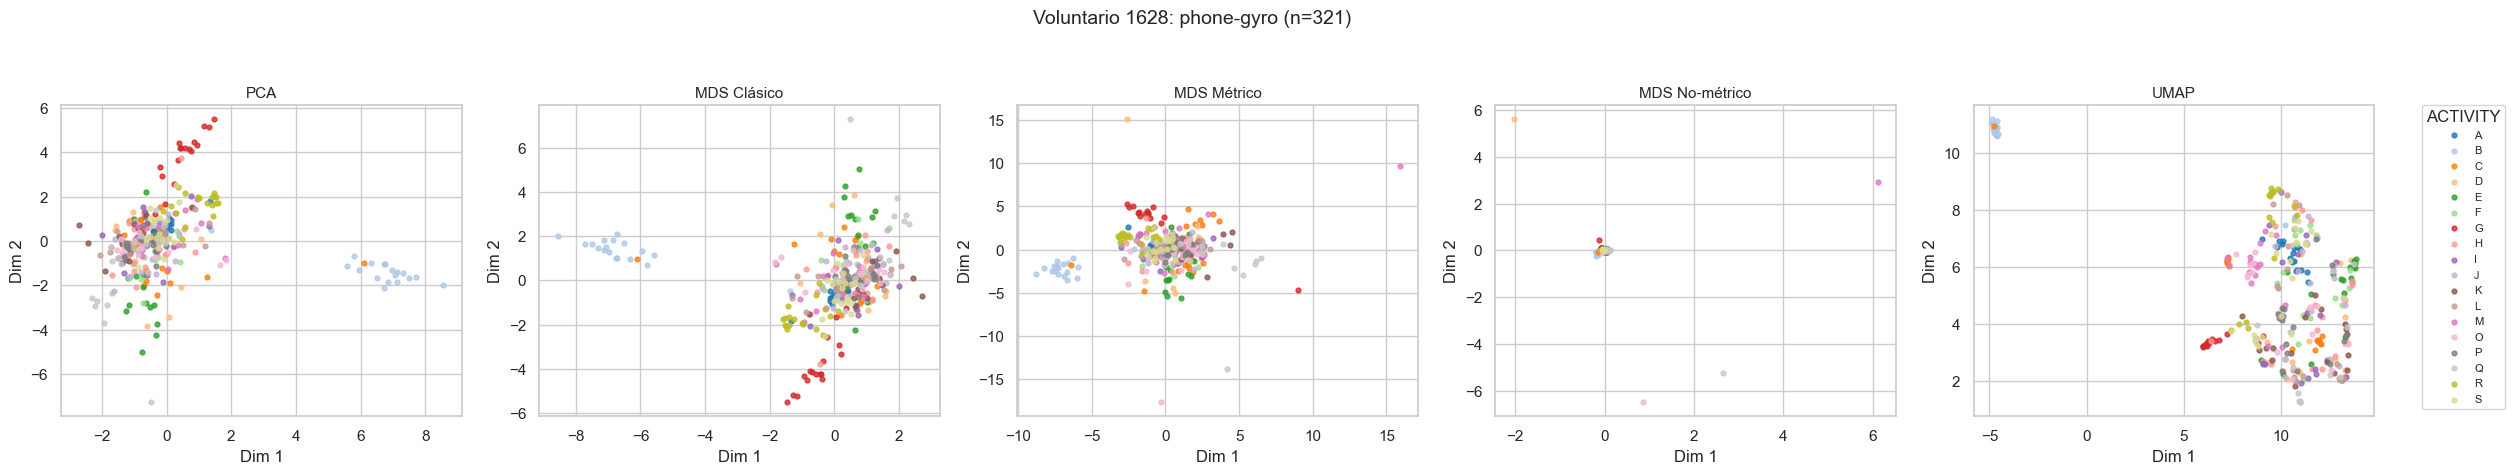

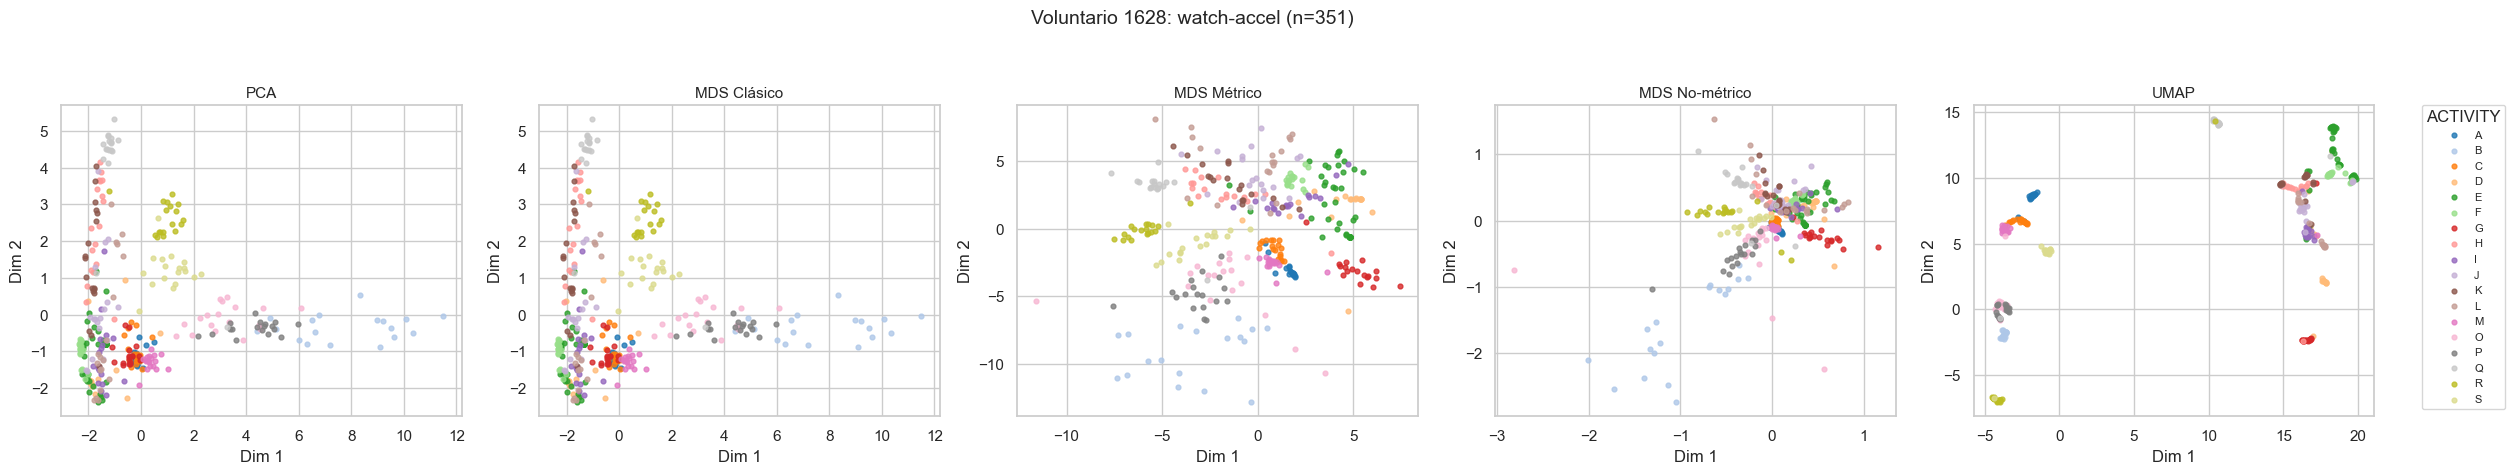

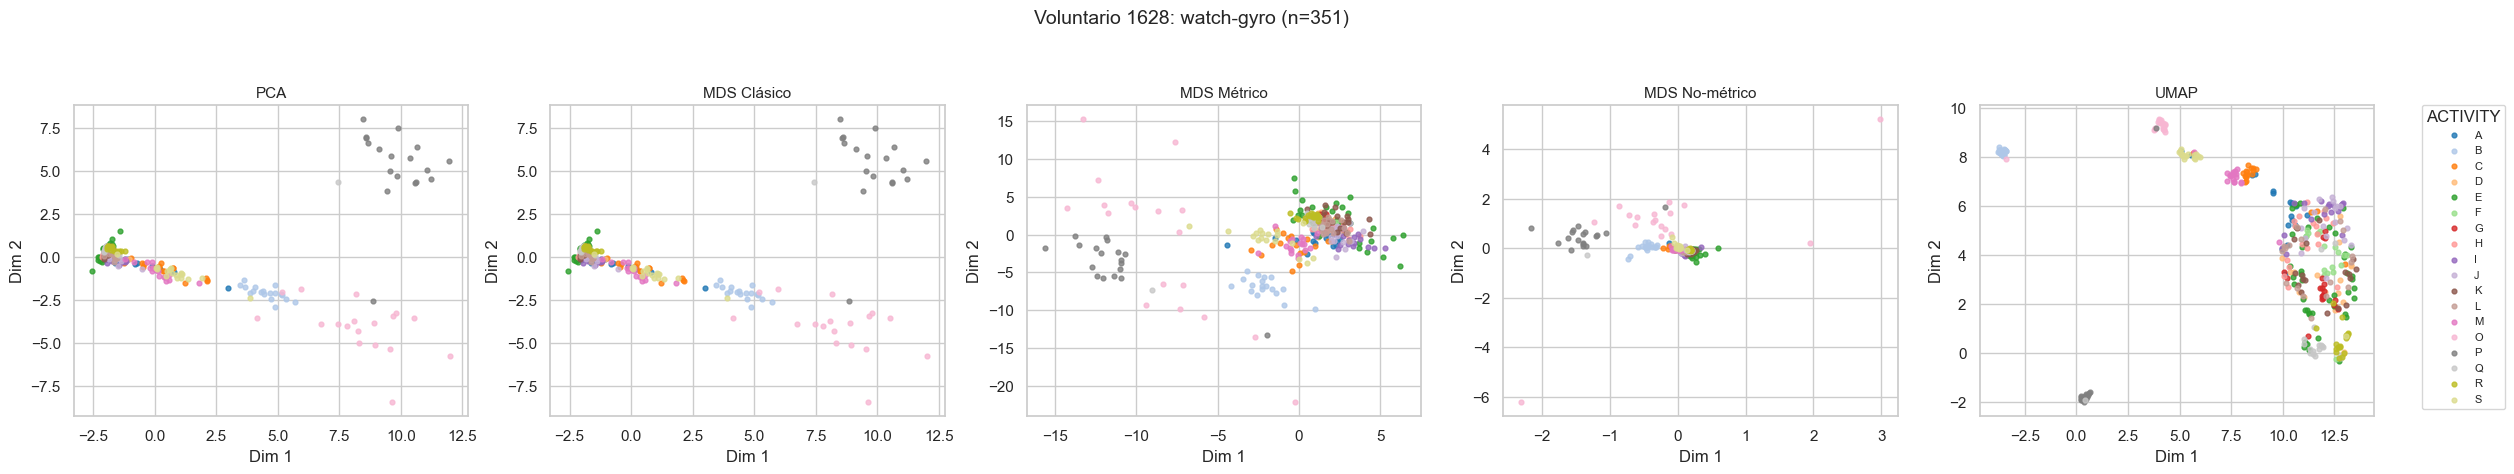


✓ Visualización individual completada


In [11]:
print("=" * 70)
print("FASE 4: Visualizando resultados individuales")
print("=" * 70 + "\n")

for (subject_id, case_name), (embeddings, y) in individual_results.items():
    plot_embeddings(
        embeddings,
        y,
        title=f"Voluntario {subject_id}: {case_name} (n={len(y)})"
    )

print("\n" + "=" * 70)
print("✓ Visualización individual completada")
print("=" * 70)


## 9. Visualización de resultados combinados

Esta celda muestra las 4 figuras combinadas, una por cada caso. Cada figura contiene PCA, MDS Clásico, MDS Métrico, MDS No-métrico y UMAP, coloreados por `ACTIVITY`.



FASE 5: Visualizando resultados combinados



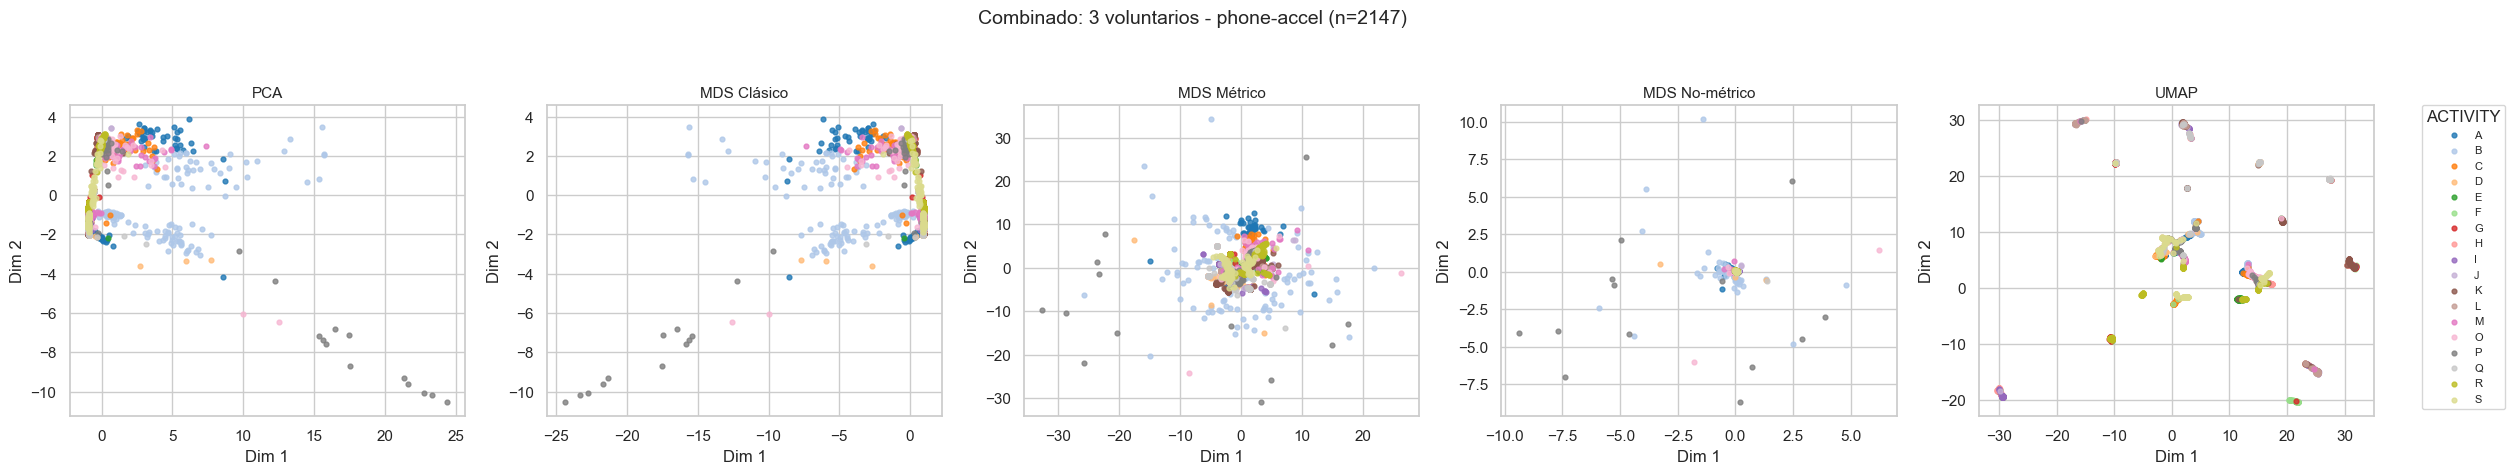

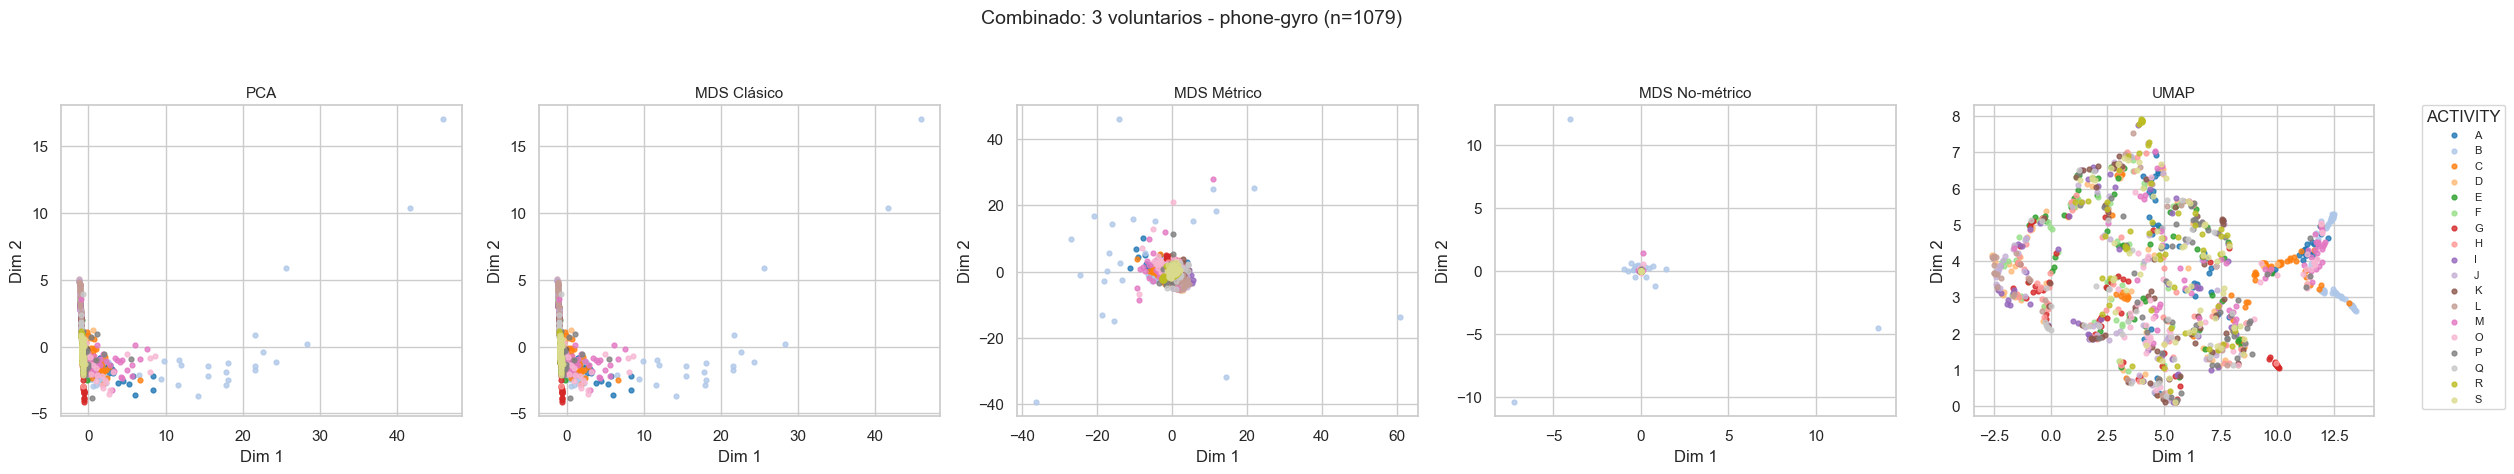

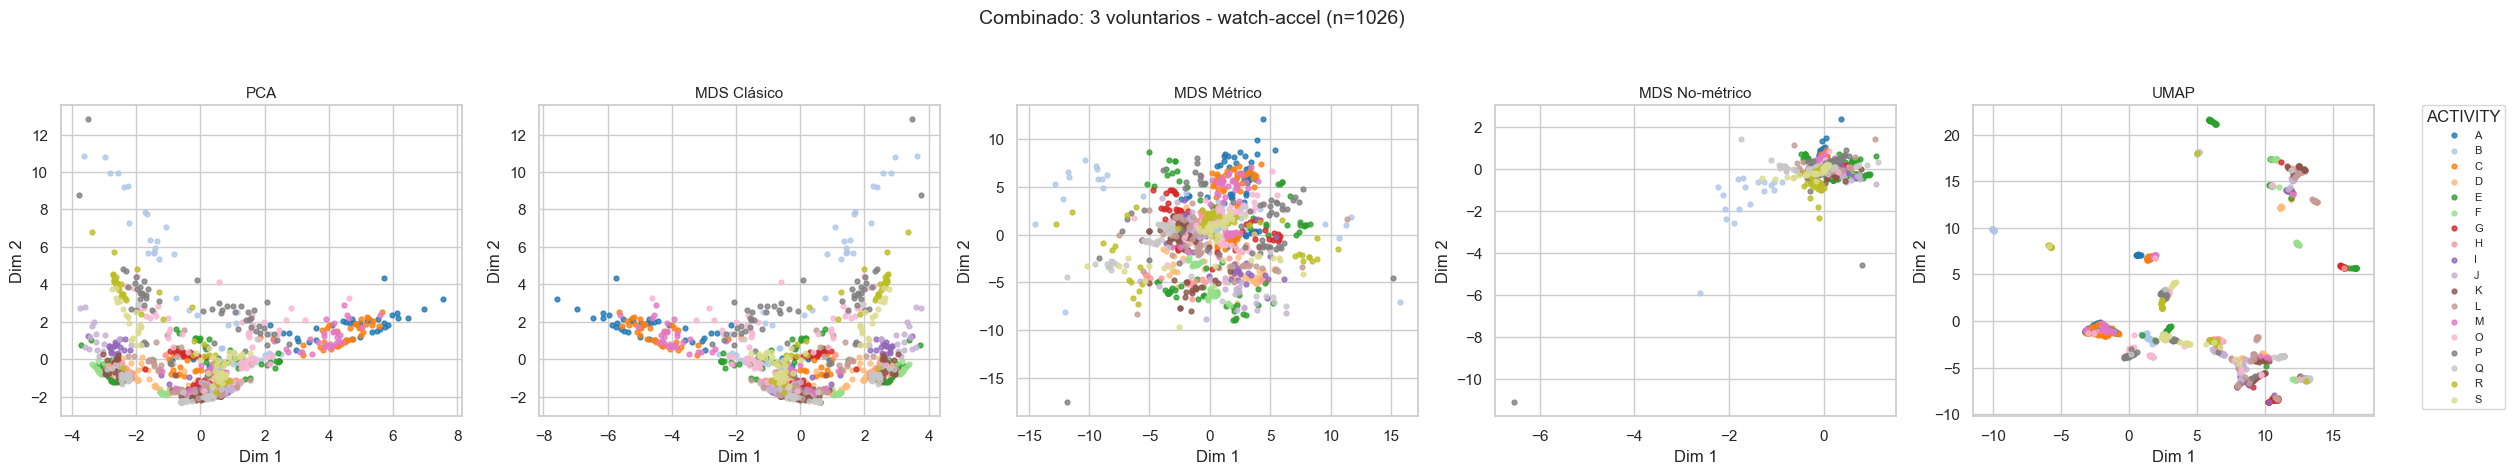

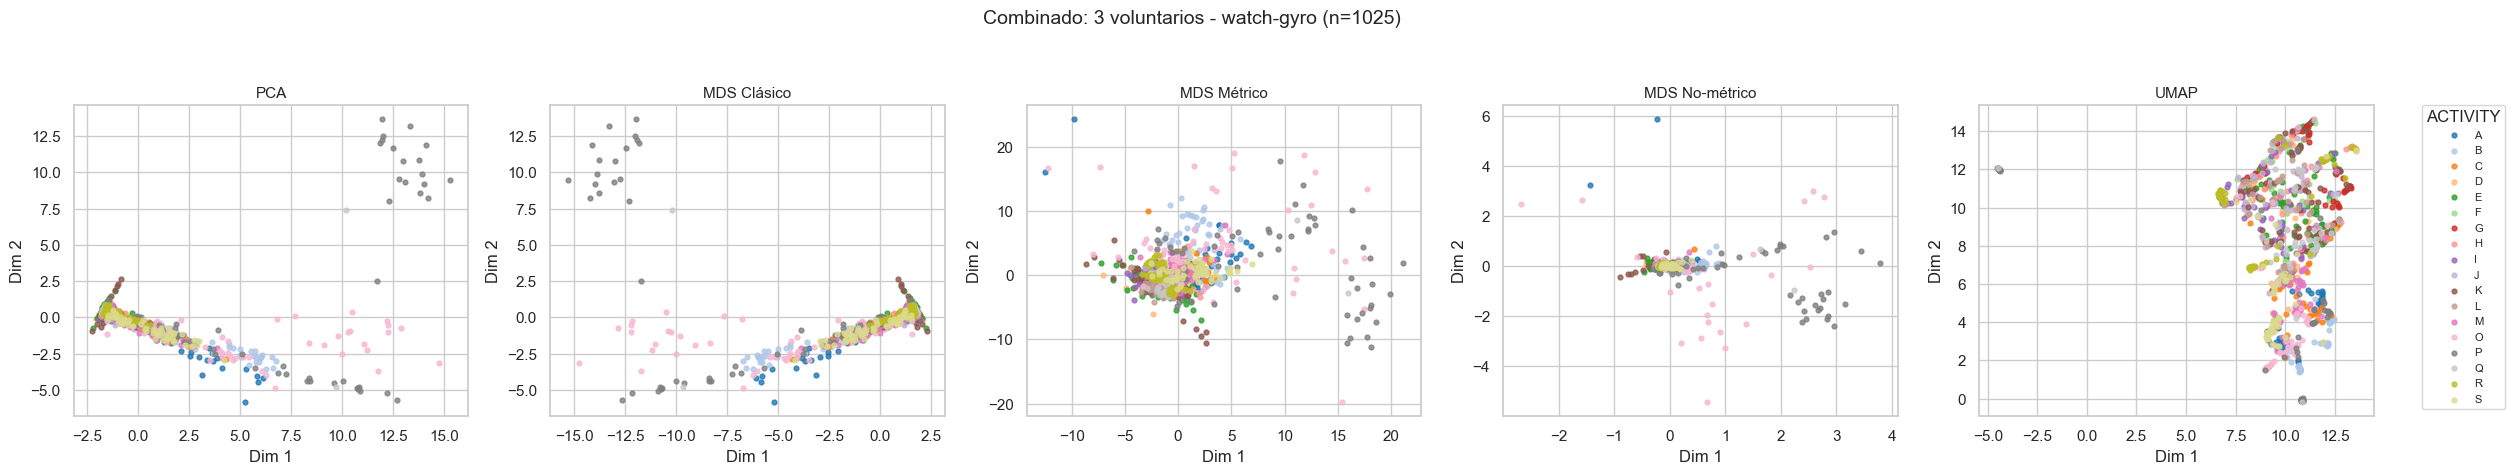


✓ Visualización combinada completada


In [12]:
print("=" * 70)
print("FASE 5: Visualizando resultados combinados")
print("=" * 70 + "\n")

for case_name, (embeddings, y_combined) in combined_results.items():
    plot_embeddings(
        embeddings,
        y_combined,
        title=f"Combinado: 3 voluntarios - {case_name} (n={len(y_combined)})"
    )

print("\n" + "=" * 70)
print("✓ Visualización combinada completada")
print("=" * 70)


## 10. Discusión

### ¿Qué actividades se diferencian mejor en dos dimensiones?

De acuerdo con las gráficas combinadas, las actividades que mejor se diferencian son principalmente las que producen movimientos amplios y repetitivos, como `WALKING (A)`, `JOGGING (B)` y `STAIRS (C)`. Estas actividades tienden a ocupar regiones distintas, especialmente en las representaciones obtenidas a partir del acelerómetro.

La separación más clara se observa en el caso `watch-accel`, donde UMAP forma varios grupos compactos y relativamente alejados entre sí. En `phone-accel` también se observa una estructura global definida con PCA y MDS clásico, aunque algunos grupos todavía se mezclan. Las actividades con patrones de movimiento más particulares, como `DRIBBLING (P)` o `CLAPPING (R)`, pueden formar agrupaciones locales, pero su separación no es igualmente consistente en todos los voluntarios y sensores.

### ¿Qué actividades se superponen en dos dimensiones?

Las actividades que más se superponen son las estáticas o las que producen movimientos pequeños y parecidos. Entre ellas se encuentran `SITTING (D)` y `STANDING (E)`, además de actividades finas como `TYPING (F)`, `TEETH (G)`, `SOUP (H)`, `CHIPS (I)`, `PASTA (J)`, `DRINKING (K)`, `SANDWICH (L)` y `WRITING (Q)`.

El solapamiento es especialmente visible en `phone-gyro` y `watch-gyro`, donde UMAP muestra estructuras curvas o circulares, pero varios colores aparecen mezclados dentro de las mismas regiones. Esto indica que las dos dimensiones no contienen suficiente información para separar completamente todas las actividades. También se observa variabilidad entre voluntarios, ya que una misma actividad no siempre aparece en la misma posición ni con el mismo nivel de compactación.

### Comparación entre técnicas

- **PCA:** muestra la estructura global de los datos y permite observar tendencias generales, pero no separa completamente las actividades con movimientos similares.
- **MDS clásico:** produce resultados muy parecidos a PCA, porque también conserva principalmente las distancias globales entre las observaciones.
- **MDS métrico:** presenta mayor dispersión y varios puntos alejados, por lo que la interpretación de los grupos es menos clara.
- **MDS no-métrico:** concentra muchos puntos en regiones pequeñas y ofrece una separación menos consistente entre actividades.
- **UMAP:** genera los grupos locales más compactos y visualmente separados, sobre todo en `watch-accel`. Sin embargo, en `phone-gyro` y `watch-gyro` todavía existe bastante mezcla entre colores, por lo que no separa perfectamente todas las clases.

En conclusión, se muestra que la reducción a dos dimensiones permite distinguir mejor las actividades de movimiento amplio que las actividades estáticas o de movimiento fino. UMAP es la técnica más útil para explorar agrupaciones locales, mientras que PCA y MDS clásico facilitan la interpretación de la estructura global. Aun así, ninguna técnica separa por completo todas las actividades, debido a la similitud de sus señales y a las diferencias entre voluntarios y sensores.